# U-Net

This notebook uses the shared preprocessing notebook before defining the model.

In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import runpy
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/wildfire_project"
)

PREPROCESSING_FILE = (
    PROJECT_ROOT
    / "shared"
    / "preprocessing.py"
)

print("Loading preprocessing.py...")

preprocessing = runpy.run_path(
    str(PREPROCESSING_FILE)
)

print("Preprocessing loaded successfully.")

Loading preprocessing.py...
Preprocessing loaded successfully.


In [4]:
run_preprocessing_smoke_test = (
    preprocessing[
        "run_preprocessing_smoke_test"
    ]
)

print("Running memory-safe preprocessing smoke test...")

run_preprocessing_smoke_test()

Running memory-safe preprocessing smoke test...
RUNNING PREPROCESSING SMOKE TEST
TFRecord files found:
  Train: 15
  Val:   2
  Test:  2
Training positive pixels: 658,270
Training negative pixels: 59,254,803
Raw pos_weight: 90.016
Clipped pos_weight: 20.000

pos_weight for BCEWithLogitsLoss: 20.000

Loading one training batch...
Train input shape:  (8, 12, 64, 64)
Train target shape: (8, 1, 64, 64)
Train mask shape:   (8, 1, 64, 64)

Loading one validation batch...
Val input shape:  (8, 12, 64, 64)
Val target shape: (8, 1, 64, 64)
Val mask shape:   (8, 1, 64, 64)

Loading one test batch...
Test input shape:  (8, 12, 64, 64)
Test target shape: (8, 1, 64, 64)
Test mask shape:   (8, 1, 64, 64)

Unique mask values: [0.0, 1.0]

PREPROCESSING SMOKE TEST PASSED


In [5]:
# ============================================================
# CELL 1 — Mount Google Drive and define project paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

# Main project folder
PROJECT_ROOT = Path("/content/drive/MyDrive/wildfire_project")

# Project subfolders
DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = PROJECT_ROOT / "shared"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create output folders if they do not already exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Check that important folders exist
print("Project root :", PROJECT_ROOT)
print("Data folder  :", DATA_DIR)
print("Shared folder:", SHARED_DIR)
print("Models folder:", MODELS_DIR)
print("Results folder:", RESULTS_DIR)

print("\nFolder checks:")
print("Data exists   :", DATA_DIR.exists())
print("Shared exists :", SHARED_DIR.exists())
print("Models exists :", MODELS_DIR.exists())
print("Results exists:", RESULTS_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root : /content/drive/MyDrive/wildfire_project
Data folder  : /content/drive/MyDrive/wildfire_project/data
Shared folder: /content/drive/MyDrive/wildfire_project/shared
Models folder: /content/drive/MyDrive/wildfire_project/models
Results folder: /content/drive/MyDrive/wildfire_project/results

Folder checks:
Data exists   : True
Shared exists : True
Models exists : True
Results exists: True


In [6]:
import runpy

# Location of the shared preprocessing file
PREPROCESSING_FILE = SHARED_DIR / "preprocessing.py"

print("Loading shared preprocessing from:")
print(PREPROCESSING_FILE)

# Run preprocessing.py and store everything it defines
preprocessing = runpy.run_path(str(PREPROCESSING_FILE))

print("\nShared preprocessing loaded successfully!")

# Get the functions and constants that the U-Net notebook needs

get_dataloaders = preprocessing["get_dataloaders"]

NUM_CHANNELS = preprocessing["NUM_CHANNELS"]
PATCH_SIZE = preprocessing["PATCH_SIZE"]

print("\nShared configuration:")
print("Number of input channels:", NUM_CHANNELS)
print("Patch size:", PATCH_SIZE)

Loading shared preprocessing from:
/content/drive/MyDrive/wildfire_project/shared/preprocessing.py

Shared preprocessing loaded successfully!

Shared configuration:
Number of input channels: 12
Patch size: 64


In [7]:
BATCH_SIZE = 16

print("Creating DataLoaders...")
print("Batch size:", BATCH_SIZE)

# Get DataLoaders from the shared preprocessing
train_loader, val_loader, test_loader, pos_weight = get_dataloaders(
    data_dir=str(DATA_DIR),
    batch_size=BATCH_SIZE,
    augment_train=True,
    num_workers=0,
)

print("\nDataLoaders created successfully!")

print("Train loader:", train_loader)
print("Validation loader:", val_loader)
print("Test loader:", test_loader)

print("\nShared positive weight:", pos_weight)

Creating DataLoaders...
Batch size: 16
TFRecord files found:
  Train: 15
  Val:   2
  Test:  2
Training positive pixels: 658,270
Training negative pixels: 59,254,803
Raw pos_weight: 90.016
Clipped pos_weight: 20.000

DataLoaders created successfully!
Train loader: <torch.utils.data.dataloader.DataLoader object at 0x7a805695b100>
Validation loader: <torch.utils.data.dataloader.DataLoader object at 0x7a7f47def950>
Test loader: <torch.utils.data.dataloader.DataLoader object at 0x7a80ded06210>

Shared positive weight: 20.0


In [8]:
import torch
import numpy as np

print("Loading one training batch...\n")

# Get one batch from the training DataLoader
train_inputs, train_targets, train_masks = next(iter(train_loader))

print("Training batch information:")
print("----------------------------------------")

print("Input shape:  ", train_inputs.shape)
print("Target shape: ", train_targets.shape)
print("Mask shape:   ", train_masks.shape)

print("\nData types:")
print("Input dtype:  ", train_inputs.dtype)
print("Target dtype: ", train_targets.dtype)
print("Mask dtype:   ", train_masks.dtype)

print("\nValue ranges:")
print("Input min:    ", train_inputs.min().item())
print("Input max:    ", train_inputs.max().item())

print("\nTarget unique values:")
print(torch.unique(train_targets))

print("\nMask unique values:")
print(torch.unique(train_masks))

Loading one training batch...

Training batch information:
----------------------------------------
Input shape:   torch.Size([16, 12, 64, 64])
Target shape:  torch.Size([16, 1, 64, 64])
Mask shape:    torch.Size([16, 1, 64, 64])

Data types:
Input dtype:   torch.float32
Target dtype:  torch.float32
Mask dtype:    torch.float32

Value ranges:
Input min:     -7.210348129272461
Input max:     13.836105346679688

Target unique values:
tensor([-1.,  0.,  1.])

Mask unique values:
tensor([0., 1.])


In [9]:
import torch
import torch.nn as nn


# ------------------------------------------------------------
# Double Convolution Block
# ------------------------------------------------------------

class DoubleConv(nn.Module):
    """
    Two consecutive 3x3 convolution layers.

    Each convolution is followed by:
        Batch Normalization
        ReLU activation
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(

            # First convolution
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            # Second convolution
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


# ------------------------------------------------------------
# U-Net
# ------------------------------------------------------------

class UNet(nn.Module):

    def __init__(self, in_channels=12, out_channels=1):
        super().__init__()

        # ====================================================
        # ENCODER
        # ====================================================

        # 64x64
        self.enc1 = DoubleConv(in_channels, 64)

        # 32x32
        self.enc2 = DoubleConv(64, 128)

        # 16x16
        self.enc3 = DoubleConv(128, 256)

        # 8x8
        self.enc4 = DoubleConv(256, 512)

        # ====================================================
        # BOTTLENECK
        # ====================================================

        # 4x4
        self.bottleneck = DoubleConv(512, 1024)

        # ====================================================
        # POOLING
        # ====================================================

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ====================================================
        # DECODER
        # ====================================================

        # 4x4 -> 8x8
        self.up4 = nn.ConvTranspose2d(
            1024, 512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(1024, 512)

        # 8x8 -> 16x16
        self.up3 = nn.ConvTranspose2d(
            512, 256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(512, 256)

        # 16x16 -> 32x32
        self.up2 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(256, 128)

        # 32x32 -> 64x64
        self.up1 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(128, 64)

        # ====================================================
        # FINAL OUTPUT
        # ====================================================

        self.final_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )


    def forward(self, x):

        # ====================================================
        # ENCODER
        # ====================================================

        # 12 x 64 x 64
        e1 = self.enc1(x)

        # 64 x 32 x 32
        e2 = self.enc2(self.pool(e1))

        # 128 x 16 x 16
        e3 = self.enc3(self.pool(e2))

        # 256 x 8 x 8
        e4 = self.enc4(self.pool(e3))

        # ====================================================
        # BOTTLENECK
        # ====================================================

        # 512 x 4 x 4
        b = self.bottleneck(self.pool(e4))

        # ====================================================
        # DECODER
        # ====================================================

        # 1024 -> 512 channels
        d4 = self.up4(b)

        # Skip connection from encoder 4
        d4 = torch.cat([d4, e4], dim=1)

        d4 = self.dec4(d4)

        # ----------------------------------------------------

        # 512 -> 256 channels
        d3 = self.up3(d4)

        # Skip connection from encoder 3
        d3 = torch.cat([d3, e3], dim=1)

        d3 = self.dec3(d3)

        # ----------------------------------------------------

        # 256 -> 128 channels
        d2 = self.up2(d3)

        # Skip connection from encoder 2
        d2 = torch.cat([d2, e2], dim=1)

        d2 = self.dec2(d2)

        # ----------------------------------------------------

        # 128 -> 64 channels
        d1 = self.up1(d2)

        # Skip connection from encoder 1
        d1 = torch.cat([d1, e1], dim=1)

        d1 = self.dec1(d1)

        # ====================================================
        # FINAL OUTPUT
        # ====================================================

        output = self.final_conv(d1)

        return output


print("U-Net architecture defined successfully.")

U-Net architecture defined successfully.


In [10]:
# ============================================================
# CELL 6 — Create U-Net and test the forward pass
# ============================================================

# Select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# ------------------------------------------------------------
# Create the U-Net model
# ------------------------------------------------------------

model = UNet(
    in_channels=NUM_CHANNELS,
    out_channels=1
)

# Move the model to GPU/CPU
model = model.to(device)

print("\nU-Net model created successfully.")


# ------------------------------------------------------------
# Count trainable parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", f"{total_params:,}")


# ------------------------------------------------------------
# Get one batch from the DataLoader
# ------------------------------------------------------------

inputs, targets, masks = next(iter(train_loader))

# Move only the inputs to the same device as the model
inputs = inputs.to(device)


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():
    outputs = model(inputs)


# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------

print("\nForward pass completed successfully!")

print("Input shape :", inputs.shape)
print("Output shape:", outputs.shape)
print("Output dtype:", outputs.dtype)

print("\nExpected output shape:")
print(f"torch.Size([{BATCH_SIZE}, 1, {PATCH_SIZE}, {PATCH_SIZE}])")

Using device: cuda

U-Net model created successfully.
Trainable parameters: 31,048,705

Forward pass completed successfully!
Input shape : torch.Size([16, 12, 64, 64])
Output shape: torch.Size([16, 1, 64, 64])
Output dtype: torch.float32

Expected output shape:
torch.Size([16, 1, 64, 64])


In [11]:

# Convert the shared positive weight into a PyTorch tensor
pos_weight_tensor = torch.tensor(
    [pos_weight],
    dtype=torch.float32,
    device=device
)

# BCEWithLogitsLoss:
# - combines Sigmoid + Binary Cross Entropy
# - gives extra importance to the positive/fire class
# - reduction="none" gives us a loss value for every pixel

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor,
    reduction="none"
)

print("Masked BCEWithLogitsLoss created successfully.")

print("Positive weight:", pos_weight)
print("Loss reduction:", "none")

Masked BCEWithLogitsLoss created successfully.
Positive weight: 20.0
Loss reduction: none


In [12]:

inputs, targets, masks = next(iter(train_loader))

# Move everything to the same device as the model
inputs = inputs.to(device)
targets = targets.to(device)
masks = masks.to(device)

# ------------------------------------------------------------
# Replace uncertain target values (-1) with 0
# ------------------------------------------------------------
#
# These pixels will eventually be ignored by the mask.
# Replacing them with 0 first prevents invalid target values
# from entering the BCE calculation.

targets_clean = torch.where(
    masks > 0,
    targets,
    torch.zeros_like(targets)
)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():
    logits = model(inputs)

# ------------------------------------------------------------
# Calculate pixel-level BCE loss
# ------------------------------------------------------------

loss_map = criterion(logits, targets_clean)

# ------------------------------------------------------------
# Apply the valid-pixel mask
# ------------------------------------------------------------

masked_loss = (
    loss_map * masks
).sum() / masks.sum().clamp_min(1.0)

print("Masked loss test completed successfully!")

print("\nShapes:")
print("Logits:       ", logits.shape)
print("Targets:      ", targets.shape)
print("Clean targets:", targets_clean.shape)
print("Mask:         ", masks.shape)
print("Loss map:     ", loss_map.shape)

print("\nLoss value:", masked_loss.item())

Masked loss test completed successfully!

Shapes:
Logits:        torch.Size([16, 1, 64, 64])
Targets:       torch.Size([16, 1, 64, 64])
Clean targets: torch.Size([16, 1, 64, 64])
Mask:          torch.Size([16, 1, 64, 64])
Loss map:      torch.Size([16, 1, 64, 64])

Loss value: 0.9783594012260437


In [13]:
print("Checking available hardware...\n")

if torch.cuda.is_available():

    print("GPU is available! ✅")
    print("GPU:", torch.cuda.get_device_name(0))

    # Use GPU
    device = torch.device("cuda")

else:

    print("GPU is NOT available.")
    print("Currently using CPU.")

    # Use CPU
    device = torch.device("cpu")


# ------------------------------------------------------------
# Move the model to the selected device
# ------------------------------------------------------------

model = model.to(device)

print("\nModel device:", next(model.parameters()).device)


# ------------------------------------------------------------
# Create Adam optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer created successfully!")
print("Optimizer: Adam")
print("Learning rate: 0.0001")

Checking available hardware...

GPU is available! ✅
GPU: Tesla T4

Model device: cuda:0

Optimizer created successfully!
Optimizer: Adam
Learning rate: 0.0001


In [ ]:
def calculate_masked_loss(model, inputs, targets, masks):
    """
    Calculate BCEWithLogitsLoss while ignoring uncertain pixels.

    Target values:
        0  = no fire
        1  = fire
       -1  = uncertain

    Mask values:
        1 = valid pixel
        0 = ignore pixel
    """

    # Move data to the same device as the model
    inputs = inputs.to(device)
    targets = targets.to(device)
    masks = masks.to(device)

    # Replace -1 uncertain targets with 0.
    # These pixels will still be ignored by the mask.
    targets_clean = torch.where(
        masks > 0,
        targets,
        torch.zeros_like(targets)
    )

    # Forward pass
    logits = model(inputs)

    # Calculate pixel-level loss
    loss_map = criterion(logits, targets_clean)

    # Keep only valid pixels
    loss = (
        loss_map * masks
    ).sum() / masks.sum().clamp_min(1.0)

    return loss, logits


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(model, loader, optimizer):
    """
    Train the model for one complete epoch.
    """

    model.train()

    total_loss = 0.0
    total_valid_pixels = 0

    for inputs, targets, masks in loader:

        # Move data to GPU
        inputs = inputs.to(device)
        targets = targets.to(device)
        masks = masks.to(device)

        # Replace uncertain target values
        targets_clean = torch.where(
            masks > 0,
            targets,
            torch.zeros_like(targets)
        )

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(inputs)

        # Pixel-level BCE loss
        loss_map = criterion(logits, targets_clean)

        # Ignore uncertain pixels
        loss = (
            loss_map * masks
        ).sum() / masks.sum().clamp_min(1.0)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Keep track of loss
        valid_pixels = masks.sum().item()

        total_loss += loss.item() * valid_pixels
        total_valid_pixels += valid_pixels

    # Average loss over all valid pixels
    epoch_loss = total_loss / max(total_valid_pixels, 1.0)

    return epoch_loss


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(model, loader):
    """
    Evaluate the model on the validation set.

    IMPORTANT:
    No model weights are updated here.
    """

    model.eval()

    total_loss = 0.0
    total_valid_pixels = 0

    # No gradients are needed during validation
    with torch.no_grad():

        for inputs, targets, masks in loader:

            # Move data to GPU
            inputs = inputs.to(device)
            targets = targets.to(device)
            masks = masks.to(device)

            # Replace uncertain target values
            targets_clean = torch.where(
                masks > 0,
                targets,
                torch.zeros_like(targets)
            )

            # Forward pass
            logits = model(inputs)

            # Pixel-level loss
            loss_map = criterion(logits, targets_clean)

            # Ignore uncertain pixels
            loss = (
                loss_map * masks
            ).sum() / masks.sum().clamp_min(1.0)

            # Track loss
            valid_pixels = masks.sum().item()

            total_loss += loss.item() * valid_pixels
            total_valid_pixels += valid_pixels

    # Average validation loss
    epoch_loss = total_loss / max(total_valid_pixels, 1.0)

    return epoch_loss


print("Training and validation functions defined successfully.")

Training and validation functions defined successfully.


In [ ]:
# Number of complete passes through the training data
NUM_EPOCHS = 20

# Where the best U-Net model will be saved
BEST_MODEL_PATH = MODELS_DIR / "unet_best.pth"

# Track the best validation loss seen so far
best_val_loss = float("inf")

# Keep track of training history
train_losses = []
val_losses = []

print("Training configuration:")
print("----------------------------------------")
print("Number of epochs:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", 1e-4)
print("Device:", device)
print("Best model path:", BEST_MODEL_PATH)

Training configuration:
----------------------------------------
Number of epochs: 20
Batch size: 16
Learning rate: 0.0001
Device: cuda
Best model path: /content/drive/MyDrive/wildfire_project/models/unet_best.pth


In [ ]:
import time

print("=" * 60)
print("STARTING U-NET TRAINING")
print("=" * 60)

training_start_time = time.time()


for epoch in range(NUM_EPOCHS):

    epoch_start_time = time.time()

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_loss = validate_one_epoch(
        model,
        val_loader
    )

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --------------------------------------------------------
    # Check whether this is the best model
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "best_val_loss": best_val_loss,
                "pos_weight": pos_weight,
            },
            BEST_MODEL_PATH
        )

        best_marker = "  <-- BEST MODEL SAVED"

    else:

        best_marker = ""

    # --------------------------------------------------------
    # Epoch timing
    # --------------------------------------------------------

    epoch_time = time.time() - epoch_start_time

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.6f} "
        f"| Val Loss: {val_loss:.6f} "
        f"| Time: {epoch_time / 60:.2f} min"
        f"{best_marker}"
    )


# ------------------------------------------------------------
# Total training time
# ------------------------------------------------------------

total_training_time = time.time() - training_start_time

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(f"Total training time: {total_training_time / 60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Best model saved to:")
print(BEST_MODEL_PATH)

STARTING U-NET TRAINING
Epoch [01/20] | Train Loss: 0.347041 | Val Loss: 0.359702 | Time: 1.85 min  <-- BEST MODEL SAVED
Epoch [02/20] | Train Loss: 0.241526 | Val Loss: 0.354097 | Time: 1.76 min  <-- BEST MODEL SAVED
Epoch [03/20] | Train Loss: 0.225337 | Val Loss: 0.359973 | Time: 1.70 min
Epoch [04/20] | Train Loss: 0.218848 | Val Loss: 0.346633 | Time: 1.68 min  <-- BEST MODEL SAVED
Epoch [05/20] | Train Loss: 0.214920 | Val Loss: 0.362684 | Time: 2.44 min
Epoch [06/20] | Train Loss: 0.211258 | Val Loss: 0.354324 | Time: 1.58 min
Epoch [07/20] | Train Loss: 0.208796 | Val Loss: 0.375526 | Time: 1.56 min
Epoch [08/20] | Train Loss: 0.206485 | Val Loss: 0.370197 | Time: 1.56 min
Epoch [09/20] | Train Loss: 0.204533 | Val Loss: 0.370451 | Time: 1.55 min
Epoch [10/20] | Train Loss: 0.203113 | Val Loss: 0.397429 | Time: 1.55 min
Epoch [11/20] | Train Loss: 0.199957 | Val Loss: 0.374995 | Time: 1.56 min
Epoch [12/20] | Train Loss: 0.199220 | Val Loss: 0.430599 | Time: 1.55 min
Epoch [13/

In [ ]:
import torch

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

# Restore the best model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Save the best epoch number
best_epoch = checkpoint["epoch"]

print("Best model loaded successfully!")
print("Best epoch:", best_epoch)
print("Best validation loss:", checkpoint["val_loss"])
print("Model device:", next(model.parameters()).device)

Best model loaded successfully!
Best epoch: 4
Best validation loss: 0.3466328911641475
Model device: cuda:0


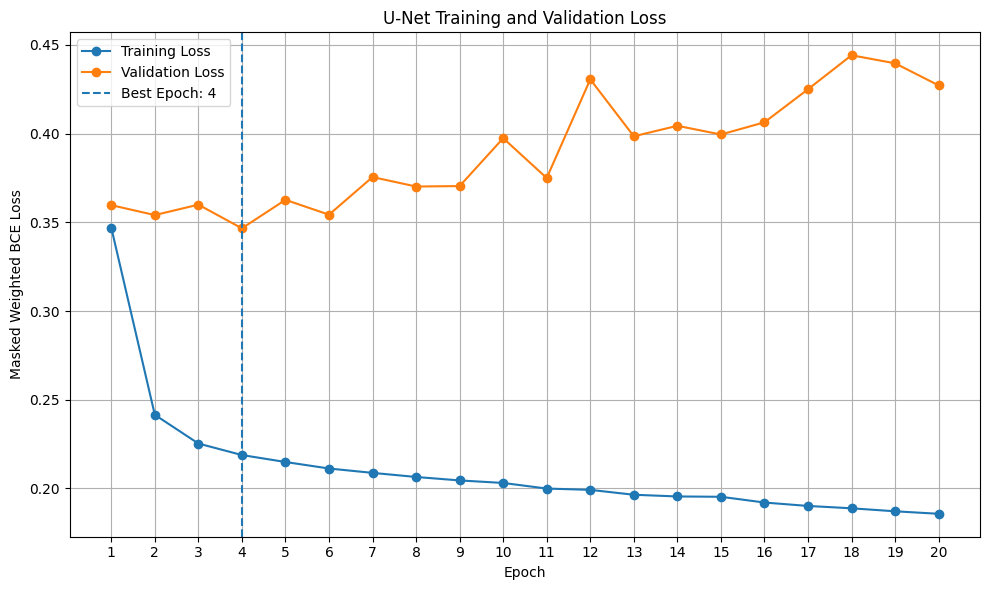

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="Training Loss",
    marker="o"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    label="Validation Loss",
    marker="o"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Masked Weighted BCE Loss")
plt.title("U-Net Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.xticks(range(1, len(train_losses) + 1))
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "unet_training_validation_loss.png",
    dpi=300
)

plt.show()

In [19]:
# CELL 15: FINAL TEST EVALUATION

import torch
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    confusion_matrix
)

model.eval()

all_predictions = []
all_targets = []

total_loss = 0.0
total_valid_pixels = 0

with torch.no_grad():

    for inputs, targets, masks in test_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)
        masks = masks.to(device)

        # Replace uncertain targets with zero for loss calculation
        targets_clean = torch.where(
            masks > 0,
            targets,
            torch.zeros_like(targets)
        )

        # Model outputs raw logits
        outputs = model(inputs)

        # Calculate masked weighted BCE loss
        loss_map = criterion(outputs, targets_clean)

        valid_pixels = masks.sum()

        loss = (
            (loss_map * masks).sum()
            / valid_pixels.clamp_min(1.0)
        )

        total_loss += loss.item() * valid_pixels.item()
        total_valid_pixels += valid_pixels.item()

        # Convert logits into probabilities
        probabilities = torch.sigmoid(outputs)

        # Threshold of 0.5
        predictions = (probabilities >= 0.5).float()

        # Keep only valid pixels
        valid_mask = masks > 0

        valid_predictions = predictions[valid_mask]
        valid_targets = targets[valid_mask]

        all_predictions.extend(
            valid_predictions.cpu().numpy().astype(int)
        )

        all_targets.extend(
            valid_targets.cpu().numpy().astype(int)
        )

# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Calculate metrics
test_loss = total_loss / max(total_valid_pixels, 1)

precision = precision_score(
    all_targets,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_targets,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_targets,
    all_predictions,
    zero_division=0
)

iou = jaccard_score(
    all_targets,
    all_predictions,
    zero_division=0
)

dice = (
    2 * precision * recall
    / (precision + recall)
    if (precision + recall) > 0
    else 0.0
)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=[0, 1]
)

print("=" * 50)
print("U-NET FINAL TEST RESULTS")
print("=" * 50)

print(f"Test Loss:  {test_loss:.6f}")
print(f"Precision:  {precision:.6f}")
print(f"Recall:     {recall:.6f}")
print(f"F1-Score:   {f1:.6f}")
print(f"IoU:        {iou:.6f}")
print(f"Dice Score: {dice:.6f}")

print("\nConfusion Matrix:")
print(cm)

print("\nValid test pixels:", total_valid_pixels)

U-NET FINAL TEST RESULTS
Test Loss:  0.265333
Precision:  0.183908
Recall:     0.776595
F1-Score:   0.297390
IoU:        0.174667
Dice Score: 0.297390

Confusion Matrix:
[[6352752  290616]
 [  18840   65491]]

Valid test pixels: 6727699.0


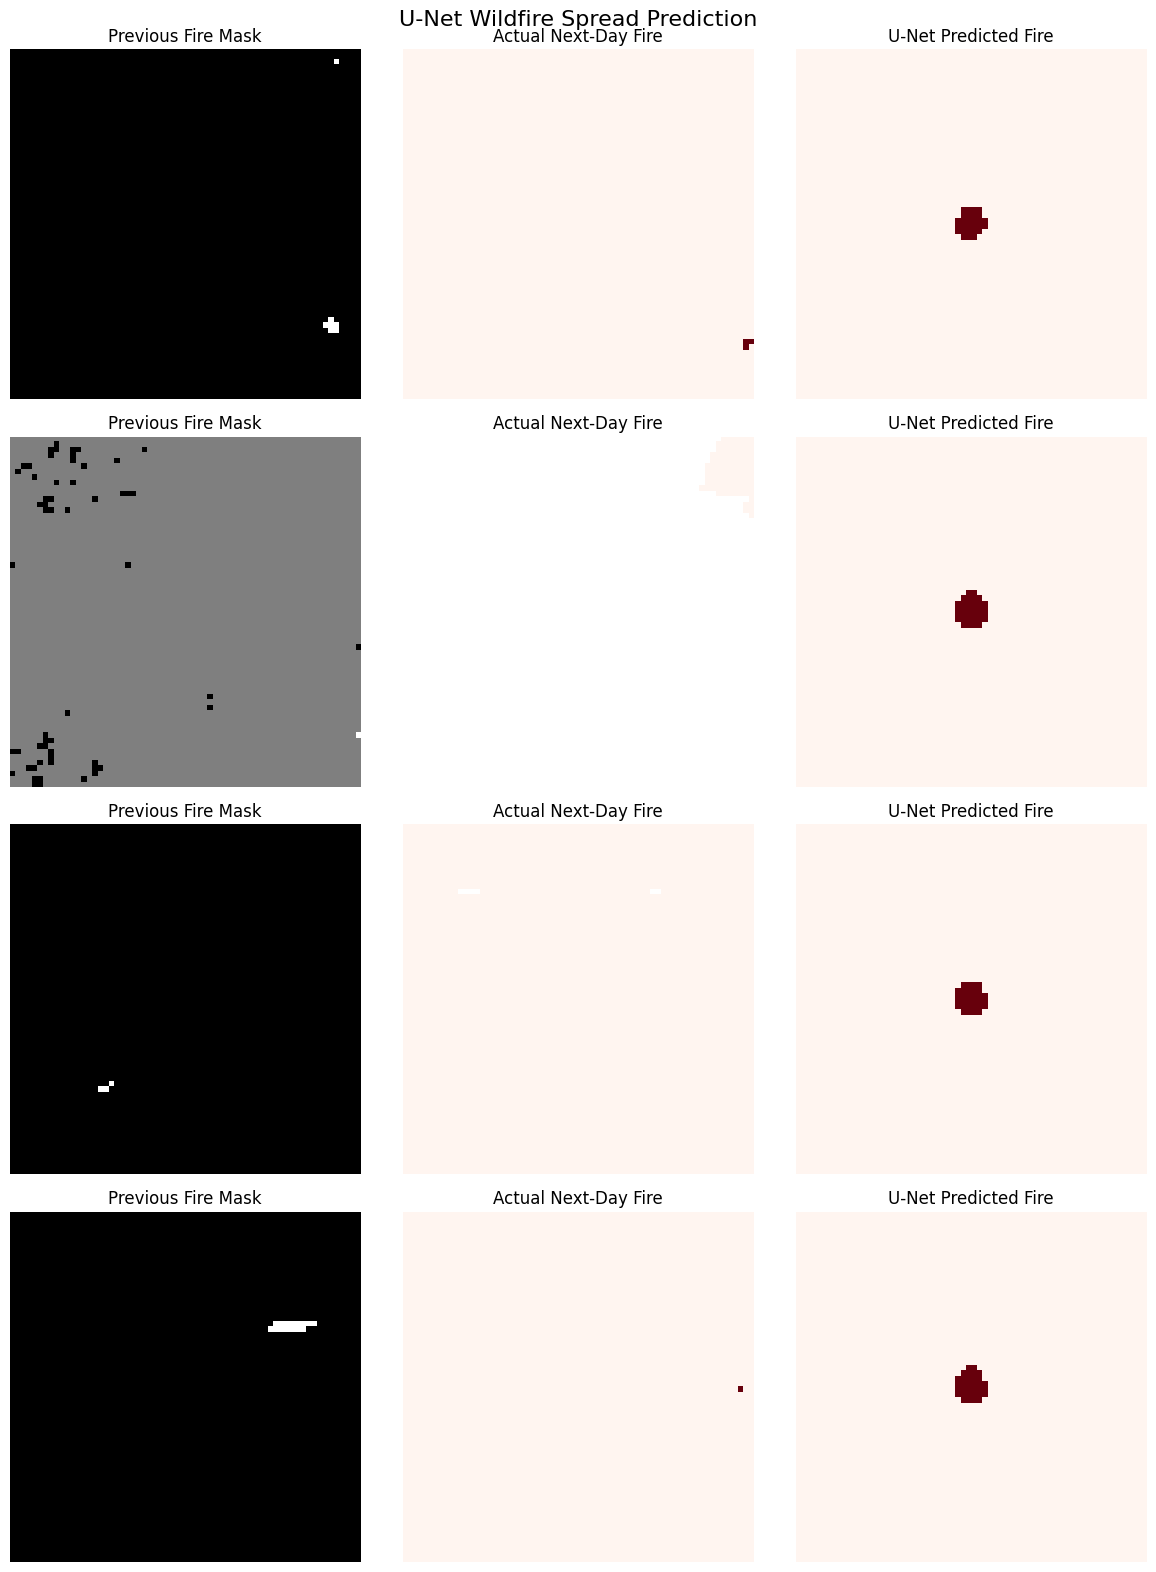

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

# Get one batch from the test dataset
inputs, targets, masks = next(iter(test_loader))

inputs = inputs.to(device)
targets = targets.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(inputs)
    probabilities = torch.sigmoid(outputs)
    predictions = (probabilities >= 0.5).float()

# Move data to CPU
inputs = inputs.cpu().numpy()
targets = targets.cpu().numpy()
masks = masks.cpu().numpy()
probabilities = probabilities.cpu().numpy()
predictions = predictions.cpu().numpy()

# Display first 4 samples
num_samples = min(4, inputs.shape[0])

fig, axes = plt.subplots(
    num_samples, 3,
    figsize=(12, 4 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_samples):

    # Input channel 11 is PrevFireMask
    previous_fire = inputs[i, 11]

    # Actual next-day fire mask
    actual_mask = targets[i, 0].copy()

    # Predicted fire mask
    predicted_mask = predictions[i, 0].copy()

    # Ignore uncertain pixels in actual mask
    actual_mask[masks[i, 0] == 0] = np.nan

    # Plot previous fire
    axes[i, 0].imshow(
        previous_fire,
        cmap="gray"
    )
    axes[i, 0].set_title("Previous Fire Mask")

    # Plot actual fire
    axes[i, 1].imshow(
        actual_mask,
        cmap="Reds",
        vmin=0,
        vmax=1
    )
    axes[i, 1].set_title("Actual Next-Day Fire")

    # Plot predicted fire
    axes[i, 2].imshow(
        predicted_mask,
        cmap="Reds",
        vmin=0,
        vmax=1
    )
    axes[i, 2].set_title("U-Net Predicted Fire")

    for j in range(3):
        axes[i, j].axis("off")

plt.suptitle(
    "U-Net Wildfire Spread Prediction",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "unet_prediction_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()